# 线性回归
> 合抱之木，生于毫末；九层之台，起于累土；千里之行，始于足下。
>
> 《道德经：第六十四章》

伟大的成就往往始于一个简单的想法。

**深度学习**（Deep Learning）也不例外。它起源于1943年一个极其朴素的数学模型：**人工神经元**（Artificial Neuron）。

## 人工神经元

人类的大脑并非一个整体的超级处理器，而是由大约 860 亿个神经元组成的复杂网络。单个神经元的能力非常有限：

1. 接收信号；
2. 判断信号强度；
3. 决定是否通知下一个神经元。

这种机制可以概括为四个步骤：**输入**、**加权**、**过滤**和**输出**。

受此启发，神经科学家麦卡洛克（McCulloch）与逻辑学家皮茨（Pitts）提出了著名的 **M-P 神经元模型**：

$$
\text{output} =
\begin{cases}
1 & \text{if } \sum\limits_{i=1}^{n} w_i x_i \geq \theta \\
0 & \text{otherwise}
\end{cases}
$$

该模型包含两个核心思想：

1. **线性回归**（Linear Regression）：对输入进行加权求和；
2. **激活函数**（Activation Function）：通过阈值 $\theta$ 对信号进行过滤，决定是否向下传递。

``💡 最初的 M-P 模型使用阶跃函数（Step Function）作为激活函数。现代深度学习则改用"连续可导"的激活函数，这是能够使用梯度下降法进行模型训练的关键。``

<div style="text-align: center;">
  <img src="images/neuron.png" width="480">
  <div>图例：人工神经元结构</div>
</div>

这里：
* $x_1$、$x_2$：输入值；
* $w_1$、$w_2$：权重；
* $p$：输出值。

## 神经网络

单个神经元能力有限，但当我们将成百上千，甚至数十亿个神经元连接并堆叠成多层结构时，就形成了功能强大的**深度神经网络**（Deep Neural Network，DNN）。

<div style="text-align: center;">
  <img src="images/deep-neural-network.png" width="480">
  <div>图例：（两层）神经网络结构</div>
</div>

这里：
* $x_1$、$x_2$：输入值；
* $H_1$、$H_2$、$H_3$、$H_4$：第一层神经元；
* $h_1$、$h_2$、$h_3$、$h_4$：中间值；
* $O$：第二层神经元；
* $p$：输出值。

现在，我们就从最简单的单神经元模型开始，逐步构建出能理解语言、生成内容的人工智能系统。

## 最简单的神经网络模型

一个仅含单个神经元的网络模型，虽然结构简单，却已经能完成许多实用任务，例如：

* 趋势预测：如房价、股票或销量预测；
* 影响分析：如健康风险评估、营销回报归因。

单个神经元的功能非常简单，就是完成一次**加权求和**（线性回归）：

$$
p = \sum_{i=1}^{n} w_i x_i + b
$$

这里：
* $x_i$：第 $i$ 个输入数据，也称为**特征值**（Feature）；
* $w_i$：对应的**权重**（Weight）；
* $b$：**偏置**（Bias）；
* $p$：加权求和的计算结果，也称为**预测值**（Prediction）。

``💡 完整的神经元模型包括线性回归和激活函数两部分。在实践中，激活函数会被单独实现，与线性回归配合使用。本章首先专注于线性回归部分。``

---

我们以一个冰激凌销量预测问题为例：

> 小明经营一家冰激凌店，发现销量与天气密切相关。他希望构建一个网络模型，根据每天的温度和湿度预测当天的冰激凌销量。
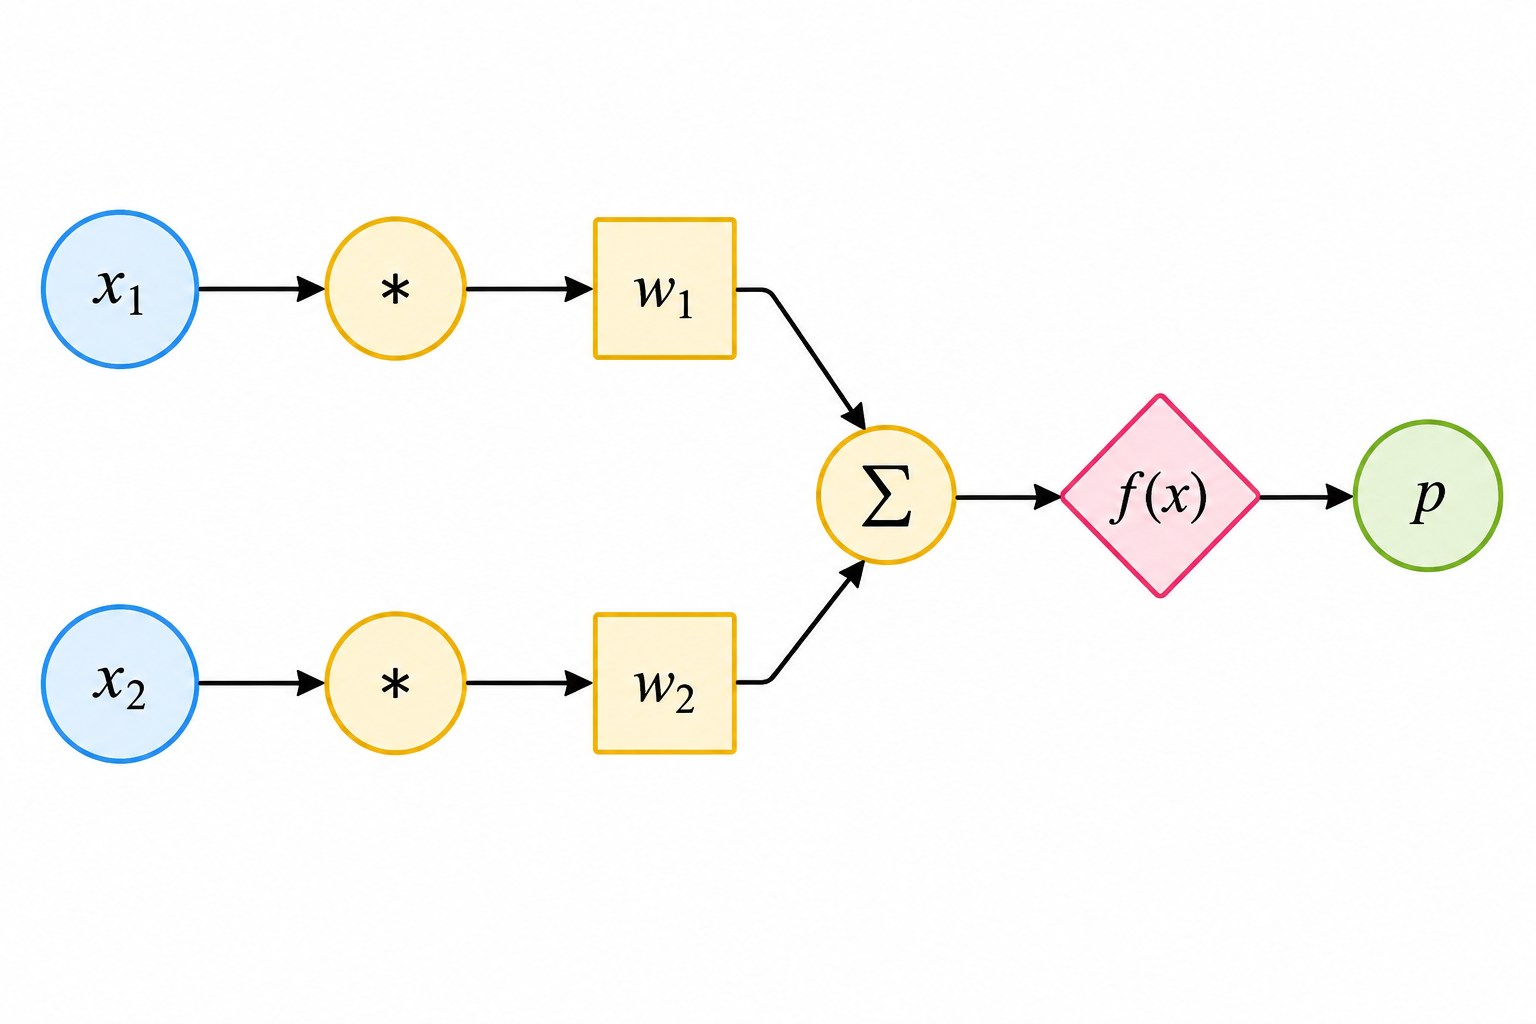

In [1]:
import numpy as np

``💡 NumPy 是 Python 的核心科学计算库，提供高效的多维数组（ndarray）和向量化运算。本书将全程使用 NumPy 实现所有计算。``

## 数据

### 特征

小明找来了今天的天气预报，于是我们有了第一组输入数据（也称为**特征**），包含两个特征值：温度 `28.1°C`，湿度 `58%`。

我们用一个 NumPy 数组保存今天的天气情况：`[温度, 湿度]`。

In [2]:
feature = np.array([28.1, 58.0])

## 模型

**模型**（Model）包含完成预测所需的全部**参数**（权重和偏置）和**计算逻辑**（推理函数）。

### 参数：权重、偏置

权重的数量和特征值的数量一一对应。比如：特征值 $[x_1, x_2]$ 包含两个数值（温度和湿度），权重也必须是两个数值：$[w_1, w_2]$。

**权重**代表每个特征值对预测结果的影响力。例如，如果 $w_1$ 很大而 $w_2$ 很小，就说明大家主要因为 $x_1$（天气太热）购买冰激凌，而非因为 $x_2$（空气潮湿）。

**偏置**只有一个数值，代表不受任何特征值影响的基础销量。比如来自铁杆冰激凌爱好者的稳定购买，无论天气如何他们都会买。

我们同样用 NumPy 数组来保存参数：

* **权重**：二维数组，格式为 `(神经元数量, 特征数量)`。每一行对应一个神经元的所有权重。而神经元的数量对应预测值的数量，每个神经元产生一个预测值。
* **偏置**：一维数组，格式为 `(神经元数量)`。每个数值对应一个神经元的偏置。

### 推理函数

推理函数实现加权求和（线性回归）的功能。这种数据从输入向输出方向的流动，称为**前向传播**（Forward Propagation）。

利用 NumPy 的矩阵运算可以高效地实现线性回归：

$$
p = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \cdot \begin{bmatrix} w_1 \\ w_2 \end{bmatrix} + b
$$

在代码中，`x @ w.T` 就等价于上面的矩阵乘法。其中 `w.T` 是对权重矩阵做**转置**（Transpose），将其格式从 `(1, 2)` 变为 `(2, 1)`，使矩阵乘法的维度能够正确匹配。计算结果是一个只包含一个数值的数组 `p`，格式为 `(1)`，也就是我们希望得到的预测值。

In [3]:
class Linear:

    def __init__(self, in_size, out_size):
        self.weight = np.ones((out_size, in_size)) / in_size
        self.bias = np.zeros(out_size)

    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):
        return x @ self.weight.T + self.bias

``💡 作为初始值，我们假设温度和湿度对销量的影响力相同，各给 0.5 的权重；偏置设为 0，因为暂时不知道稳定基础销量是多少。这两个假设并不准确。模型训练的目标，正是从数据中自动找到更好的参数。``

以上短短几行代码，我们已经构建出一个最简单的可以运行的神经网络！

## 建模

首先我们创建一个网络模型的实例。

In [4]:
layer = Linear(2, 1)

## 推理

运行网络模型的实例进行预测的过程，称为**模型推理**（Model Inference）。

现在，让我们的网络模型帮小明预测一下今天的冰激凌销量。

In [5]:
prediction = layer(feature)
print(f'prediction:\t{prediction}')

prediction:	[43.05]


模型预测：今天小明大概可以卖出 `43` 个冰激凌。

这个预测靠谱吗？等到晚上实际销售数据出炉，我们就知道答案了。

## 课后练习

如果想添加更多的特征值（比如：风速），模型的哪些部分需要调整？分别应该怎么改？